In [5]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix



In [6]:
df = pd.read_csv('ecommerce_dataset.csv')


df = df.dropna()


target = 'Purchased'

X = df.drop(target, axis=1)
y = df[target]

# Convert categorical → numeric
X = pd.get_dummies(X)



In [7]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


gini_model = DecisionTreeClassifier(
    criterion='gini',
    random_state=42
)

gini_model.fit(X_train, y_train)
y_pred_gini = gini_model.predict(X_test)


entropy_model = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42
)

entropy_model.fit(X_train, y_train)
y_pred_entropy = entropy_model.predict(X_test)


print("Gini Accuracy:", accuracy_score(y_test, y_pred_gini))
print("Entropy Accuracy:", accuracy_score(y_test, y_pred_entropy))



Gini Accuracy: 0.48333333333333334
Entropy Accuracy: 0.4166666666666667


Best Depth: 2


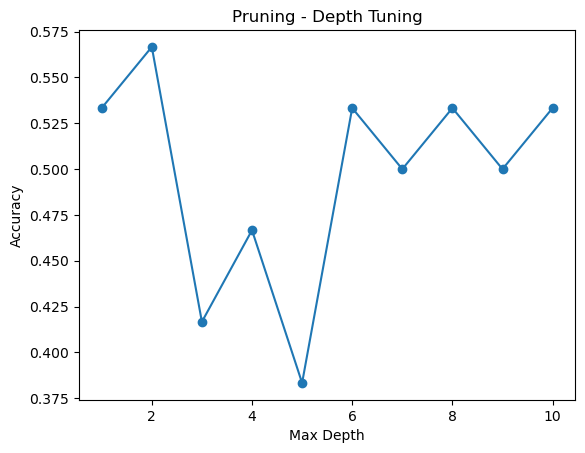

In [8]:

depths = range(1, 11)
scores = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    scores.append(accuracy_score(y_test, y_pred))

best_depth = depths[scores.index(max(scores))]
print("Best Depth:", best_depth)

# Plot depth vs accuracy
plt.plot(depths, scores, marker='o')
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Pruning - Depth Tuning")
plt.show()



Top Features:
 Time_Spent_Minutes           0.57722
Spending_Score               0.42278
Age                          0.00000
Annual_Income                0.00000
Purchase_Amount              0.00000
Discount_Used                0.00000
Gender_Female                0.00000
Gender_Male                  0.00000
Product_Category_Beauty      0.00000
Product_Category_Clothing    0.00000
dtype: float64


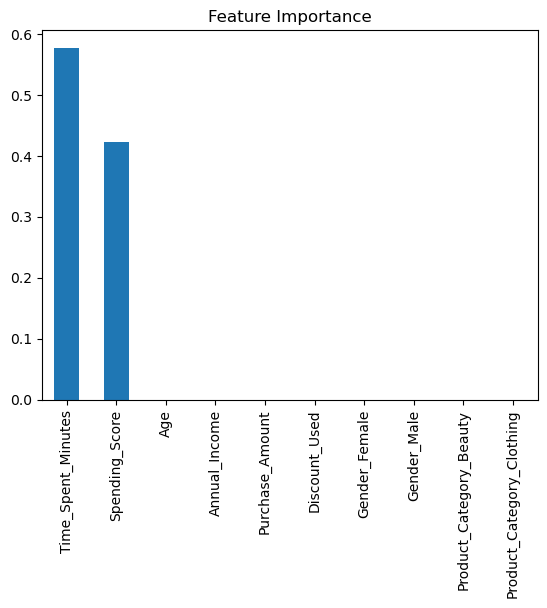

In [9]:


final_model = DecisionTreeClassifier(
    max_depth=best_depth,
    random_state=42
)

final_model.fit(X_train, y_train)


importances = pd.Series(
    final_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\nTop Features:\n", importances.head(10))

# Plot feature importance
importances.head(10).plot(kind='bar')
plt.title("Feature Importance")
plt.show()


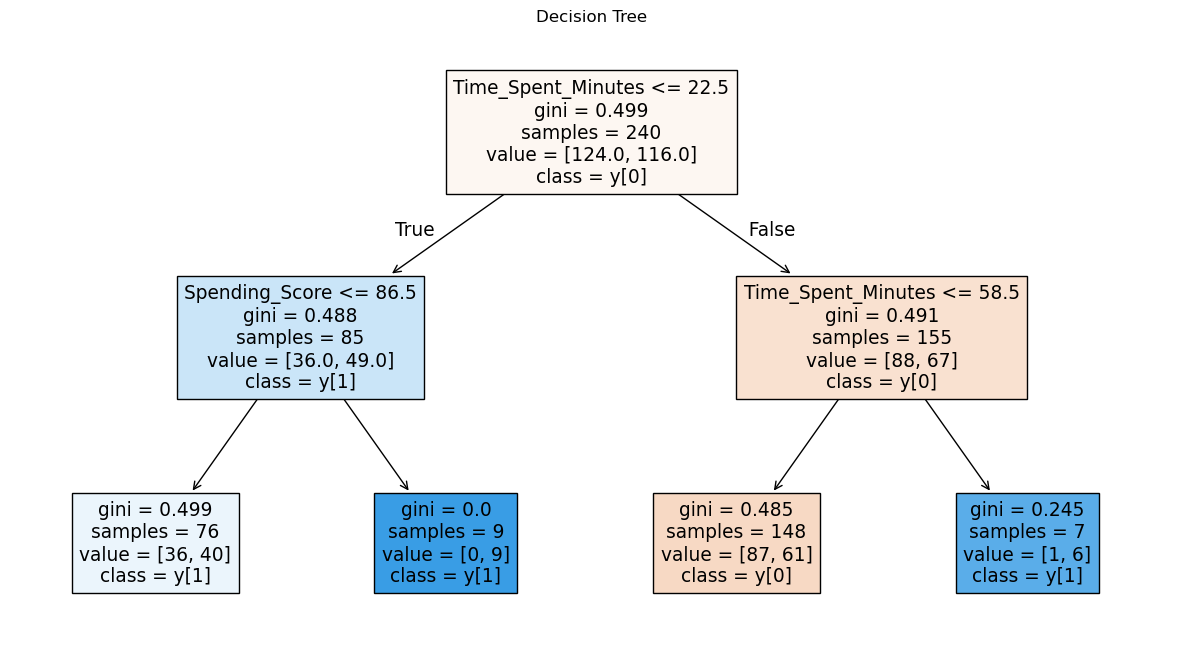

In [10]:
plt.figure(figsize=(15,8))
plot_tree(
    final_model,
    feature_names=X.columns,
    class_names=True,
    filled=True
)
plt.title("Decision Tree")
plt.show()


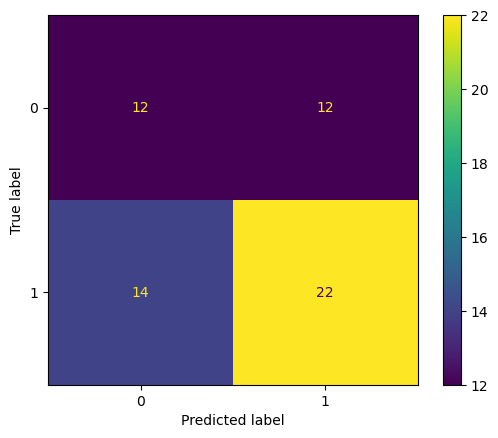

In [11]:
from sklearn.metrics import ConfusionMatrixDisplay

y_pred_final = final_model.predict(X_test)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_final)
plt.show()